## IIP314W Optimización aplicada a negocios

### Ayudantía 1

## Repaso conceptual

### Formulación de un problema

Un problema de optimización requiere de:

> Variables de decisión.
> 
> Función objetivo.
> 
> Restricciones (igualdad/desigualdad).

Forma general:

$$\min f(x) \quad \text{sujeto a } g_i(x)\le 0,\; h_j(x)=0$$

### Puntos críticos y clasificación

- Punto crítico: $f'(x)=0$ (1D) o $\nabla f(x)=0$ (multivariable).
- Clasificación local: máximo, mínimo o silla/inflexión.
- Criterio de segundo orden: signo de segunda derivada (1D) o Hessiano (multivariable).

### Equivalencia max -> -min

$$\max f(x) = \min(-f(x))$$

> Usar esta equivalencia permite resolver sistemáticamente en formato de minimización.

### Descenso de gradiente (resumen operativo)

Actualización iterativa:

$$x_{k+1}=x_k-\alpha\nabla f(x_k)$$

Parámetros críticos:

- Inicialización $x_0$.--> Valor de X inicial
- Tasa de aprendizaje $\alpha$. --> Paso o razón de cambio
- Tolerancia --> diferencia entre el paso actual y el anterior mínima para seguir iterando.
- Máximo de iteraciones. --> se explica solo.

### Ejercicio 1 (1 variable)

Considere:

$$f(t)=-t^2+6t,\quad t\in[0,6]$$

**Tareas**:
1. Calcular $f'(t)$ y resolver $f'(t)=0$.
2. Clasificar el punto crítico con segunda derivada.
3. Verificar el valor de la función en extremos y punto crítico.

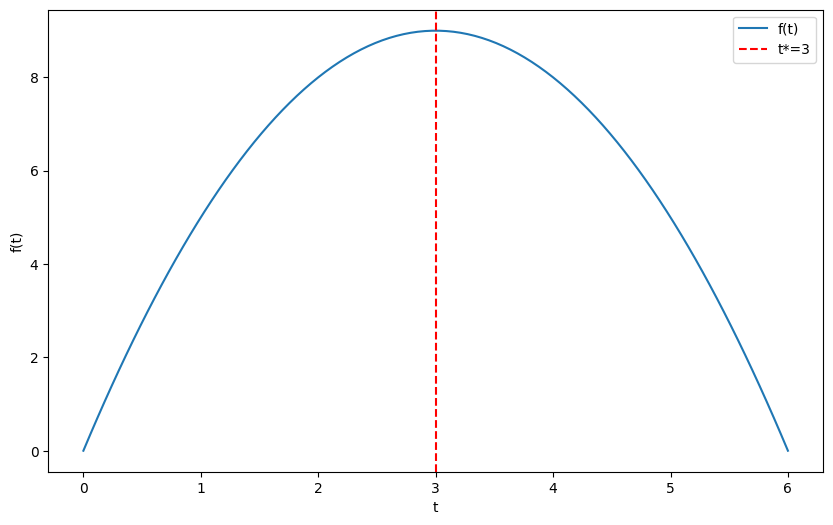

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda t: -t**2 + 6*t
df = lambda t: -2*t + 6

t_optimo = 3

valores = np.linspace(0, 6, 100)
plt.figure(figsize=(10,6))
plt.plot(valores, f(valores), label='f(t)')
plt.axvline(t_optimo, color='red', linestyle='--', label='t*=3')
plt.legend()
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

### Ejercicio 2 (2 variables)

Considere:

$$f(x,y)=2x^2-xy+y^2-7y$$

**Tareas**:
1. Hallar $\nabla f(x,y)$.
2. Resolver sistema de primer orden para el punto estacionario.
3. Clasificar usando Hessiano.

In [3]:
import sympy as sp

x, y = sp.symbols('x y', real=True)
f = 2*x**2 - x*y + y**2 - 7*y

grad = [sp.diff(f, x), sp.diff(f, y)]
sol = sp.solve(grad, (x, y), dict=True)
H = sp.hessian(f, (x, y))

print(grad)
print(sol)
display(H)
print(H.det())
print(H[0,0])

[4*x - y, -x + 2*y - 7]
[{x: 1, y: 4}]


Matrix([
[ 4, -1],
[-1,  2]])

7
4


### Ejercicio 3 (descenso de gradiente sobre función cuadrática)

Considere:

$$q(x)=(x+1)^2$$

**Tareas**:
1. Implementar descenso de gradiente en 1D.
2. Evaluar sensibilidad frente a diferentes $\alpha$.
3. Registrar iteraciones hasta criterio de parada.

In [4]:
q = lambda x: (x+1)**2
dq = lambda x: 2*(x+1)

def gd_1d(x0, alpha=0.1, tol=1e-6, max_iters=200):
    x = x0
    hist = [x]
    for _ in range(max_iters):
        x_new = x - alpha*dq(x)
        hist.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x_new, hist

x_opt, history = gd_1d(10, alpha=0.2)
x_opt, q(x_opt), len(history)-1

(-0.9999985409121298, 2.1289374129430454e-12, 31)

## Graficado (para ver si se entiende mejor)
Esto no lo hice en la ayudantía, pero les va a servir para entender un poco mejor la diferencia en parametros (en este caso, el alpha)

Text(0.5, 1.0, 'Gradient Descent Trajectory with alpha = 0.1')

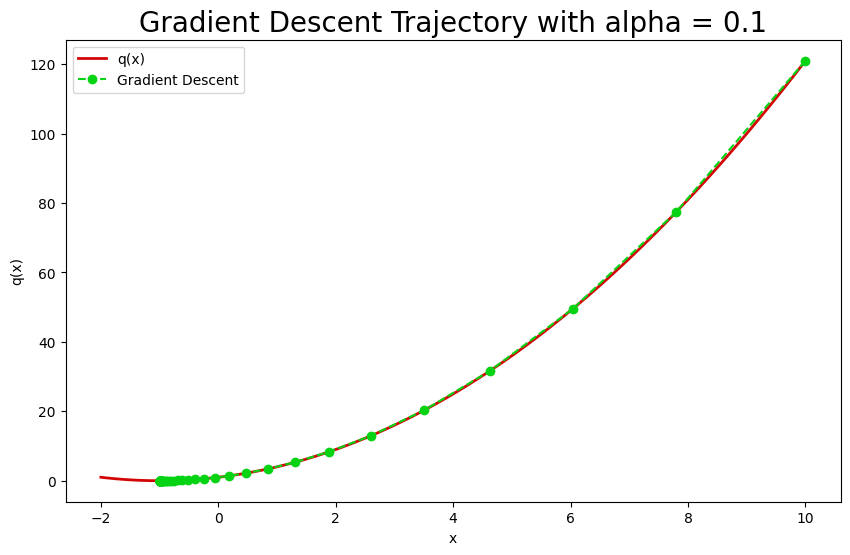

In [22]:
q = lambda x: (x+1)**2
dq = lambda x: 2*(x+1)

def gd_1d(x0, alpha=0.1, tol=1e-6, max_iters=200):
    x = x0
    hist = [x]
    histy = [q(x)]
    for _ in range(max_iters):
        x_new = x - alpha*dq(x)
        hist.append(x_new)
        histy.append(q(x_new))
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x_new, hist, histy

x_opt, history, history_y = gd_1d(10)
values = np.linspace(-2, 10, 100)
values_y = q(values)
plt.figure(figsize=(10,6))
plt.plot(values, values_y, '-', linewidth=2, color="#d30606", label='q(x)')
plt.plot(history, history_y, '--', marker='o', color="#06d314", label='Gradient Descent')
plt.legend()
plt.xlabel('x')
plt.ylabel('q(x)')
plt.title('Gradient Descent Trajectory with alpha = 0.1', fontsize=20)

Text(0.5, 1.0, 'Gradient Descent Trajectory with alpha = 0.5')

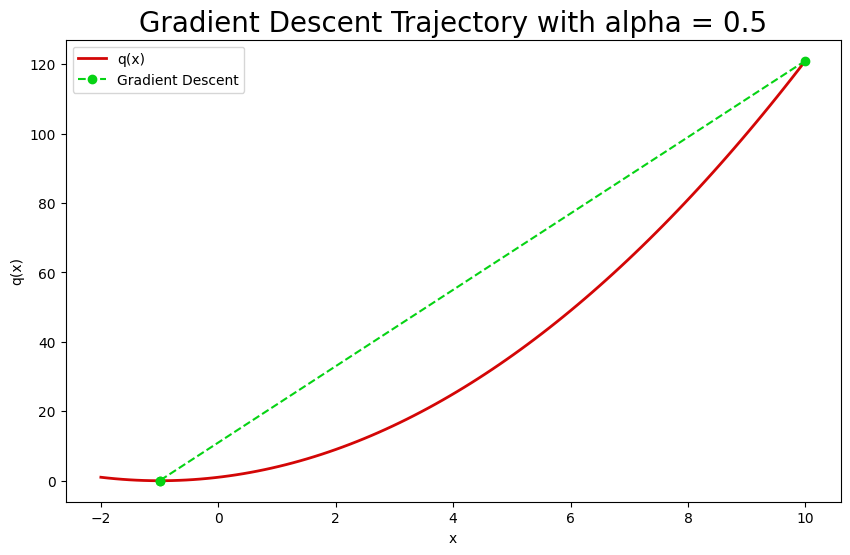

In [23]:
x_opt, history, history_y = gd_1d(10, alpha=0.5)
values = np.linspace(-2, 10, 100)
values_y = q(values)
plt.figure(figsize=(10,6))
plt.plot(values, values_y, '-', linewidth=2, color="#d30606", label='q(x)')
plt.plot(history, history_y, '--', marker='o', color="#06d314", label='Gradient Descent')
plt.legend()
plt.xlabel('x')
plt.ylabel('q(x)')
plt.title('Gradient Descent Trajectory with alpha = 0.5', fontsize=20)

Text(0.5, 1.0, 'Gradient Descent Trajectory with alpha = 0.8')

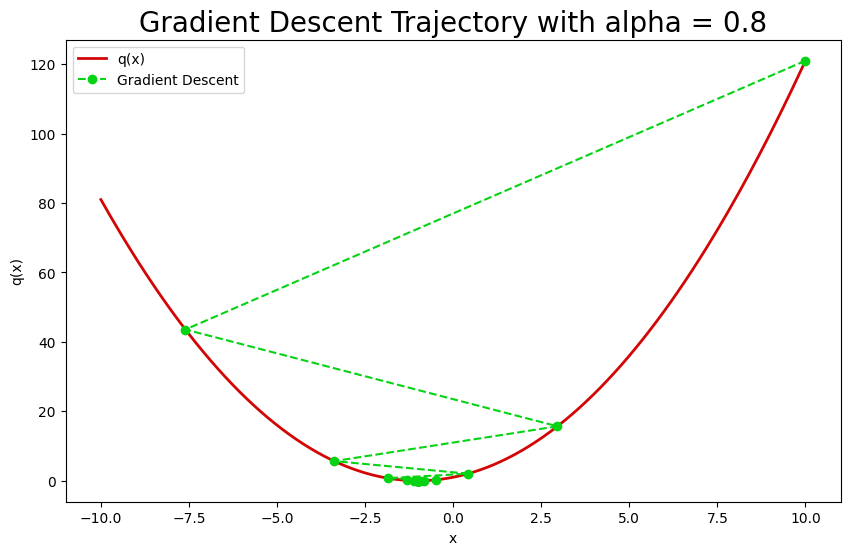

In [24]:
x_opt, history, history_y = gd_1d(10, alpha=0.8)
values = np.linspace(-10, 10, 200)
values_y = q(values)
plt.figure(figsize=(10,6))
plt.plot(values, values_y, '-', linewidth=2, color="#d30606", label='q(x)')
plt.plot(history, history_y, '--', marker='o', color="#06d314", label='Gradient Descent')
plt.legend()
plt.xlabel('x')
plt.ylabel('q(x)')
plt.title('Gradient Descent Trajectory with alpha = 0.8', fontsize = 20)

## Ejercicios propuestos.

### 1)

Para $f(x)=x^4-4x^2$, determine todos los puntos críticos y clasifíquelos. Indique cuáles son mínimos globales.

### 2)

Para $f(x,y)=x^2+y^2-2x-4y+5$, encuentre el punto estacionario y clasifíquelo con Hessiano.

### 3)

Plantee una función objetivo simple de negocio (costo o utilidad) con una restricción de desigualdad y una de igualdad. Defina claramente variable, objetivo y región factible.

### 4)

Implemente descenso de gradiente para $f(x)=x^2+2x+1$ desde tres puntos iniciales distintos y compare iteraciones requeridas para converger con igual tolerancia.